# Folder Distribution — tejo9855 Annotations

Folder breakdown of texts annotated by tejo9855 across all three annotation tasks: agency, event relations, and setting. Uses `folder` rather than `source` to distinguish Common Crawl subsets (head/middle/tail, web vs. news).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

ANNOTATOR = 'tejo9855'

FOLDER_PALETTE = {
    'cc_en_head':               '#1f77b4',
    'cc_en_middle':             '#4da3e0',
    'cc_en_tail':               '#aec7e8',
    'cc_news_head':             '#d62728',
    'cc_news_middle':           '#e87070',
    'cc_news_tail':             '#f2b4b4',
    'falcon-refinedweb-filtered': '#ff7f0e',
    'reddit':                   '#2ca02c',
    'c4-filtered':              '#9467bd',
    'books':                    '#8c564b',
    'wiki':                     '#e377c2',
    'wikiref_megawika':         '#bcbd22',
}

In [ ]:
from nb_utils import load

agency_df  = load('agency')
event_df   = load('event_relation')
setting_df = load('setting')

# Annotation columns for this annotator. annotation_order_* is bookkeeping, not
# a label, so it is excluded.
def label_cols(df):
    return [c for c in df.columns
            if c.endswith(f'_{ANNOTATOR}') and not c.startswith('annotation_order')]

agency_cols  = label_cols(agency_df)
event_cols   = label_cols(event_df)
setting_cols = label_cols(setting_df)

print('Agency annotation cols:  ', agency_cols)
print('Event-relation cols:     ', event_cols)
print('Setting annotation cols: ', setting_cols)
print()
print(f'Rows  — agency: {len(agency_df)}, event: {len(event_df)}, setting: {len(setting_df)}')


## 1. Overall folder distribution per task

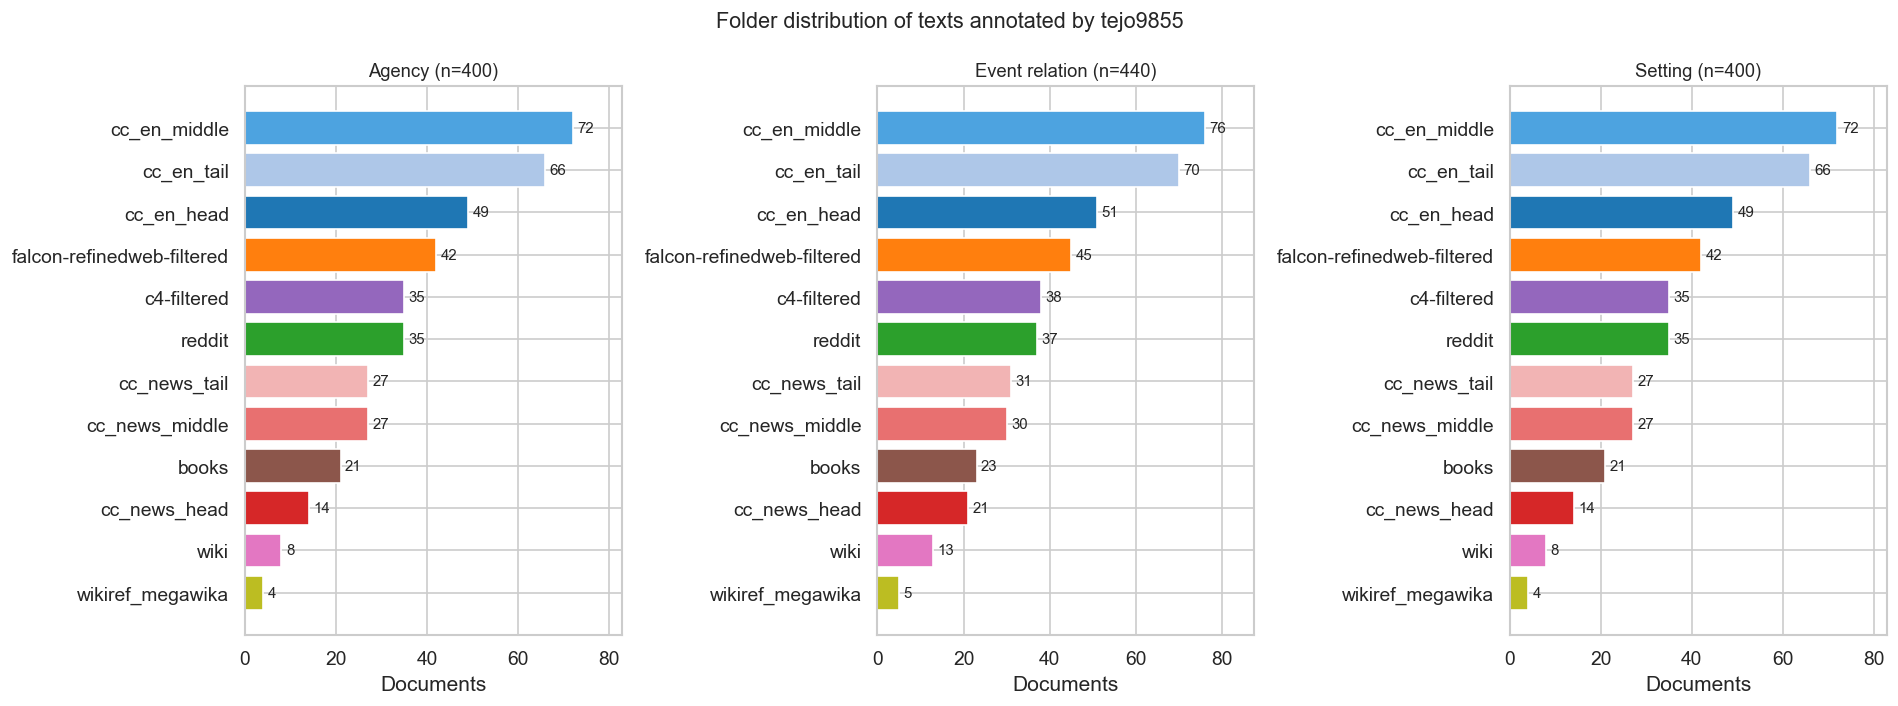

In [3]:
task_frames = {
    'Agency':         agency_df,
    'Event relation': event_df,
    'Setting':        setting_df,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (task, df) in zip(axes, task_frames.items()):
    counts = df['folder'].value_counts().sort_values(ascending=True)
    colors = [FOLDER_PALETTE.get(s, '#aec7e8') for s in counts.index]
    bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)
    ax.set_title(f'{task} (n={len(df)})', fontsize=11)
    ax.set_xlabel('Documents')
    ax.set_xlim(0, counts.max() * 1.15)

plt.suptitle(f'Folder distribution of texts annotated by {ANNOTATOR}', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Side-by-side comparison across tasks

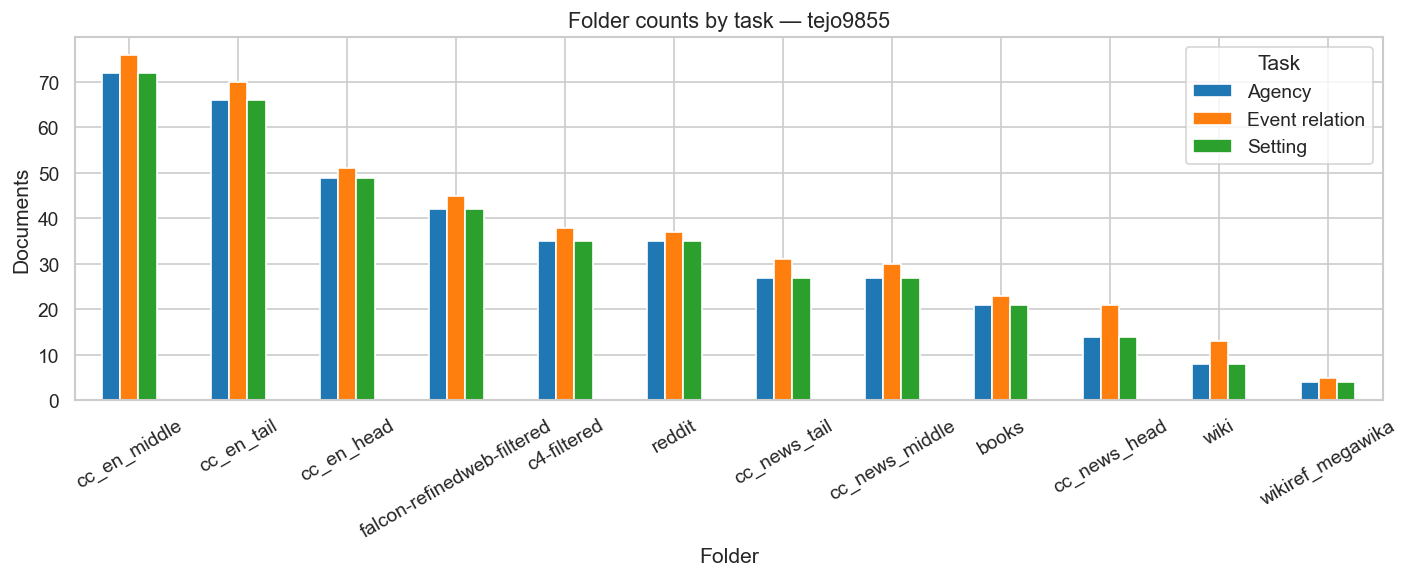

                            Agency  Event relation  Setting
folder                                                     
cc_en_middle                    72              76       72
cc_en_tail                      66              70       66
cc_en_head                      49              51       49
falcon-refinedweb-filtered      42              45       42
c4-filtered                     35              38       35
reddit                          35              37       35
cc_news_tail                    27              31       27
cc_news_middle                  27              30       27
books                           21              23       21
cc_news_head                    14              21       14
wiki                             8              13        8
wikiref_megawika                 4               5        4

Row totals:
folder
cc_en_middle                  220
cc_en_tail                    202
cc_en_head                    149
falcon-refinedweb-filtered    129
c4-f

In [4]:
combined = pd.DataFrame({
    task: df['folder'].value_counts()
    for task, df in task_frames.items()
}).fillna(0).astype(int)

combined = combined.loc[combined.sum(axis=1).sort_values(ascending=False).index]

ax = combined.plot(
    kind='bar', figsize=(12, 5), edgecolor='white',
    color=['#1f77b4', '#ff7f0e', '#2ca02c']
)
ax.set_title(f'Folder counts by task — {ANNOTATOR}', fontsize=13)
ax.set_xlabel('Folder')
ax.set_ylabel('Documents')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Task')
plt.tight_layout()
plt.show()

print(combined)
print()
print('Row totals:')
print(combined.sum(axis=1))

## 3. Folder proportions (normalised)

In [ ]:
proportions = combined.div(combined.sum(axis=0), axis=1) * 100

ax = proportions.T.plot(
    kind='bar', stacked=True, figsize=(8, 5), edgecolor='white',
    color=[FOLDER_PALETTE.get(s, '#aec7e8') for s in proportions.index]
)
ax.set_title(f'Folder proportions by task (%) — {ANNOTATOR}', fontsize=13)
ax.set_xlabel('Task')
ax.set_ylabel('Percentage')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Folder', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(proportions.round(1))

## 4. Agency annotations by folder

In [ ]:
# Proportion of positive (True) labels per agency dimension, broken down by folder
fig, axes = plt.subplots(1, len(agency_cols), figsize=(4 * len(agency_cols), 6), sharey=True)

short_names = {c: c.replace('agency_', '').replace(f'_{ANNOTATOR}', '') for c in agency_cols}

for ax, col in zip(axes, agency_cols):
    rates = agency_df.groupby('folder')[col].apply(lambda x: (x == True).mean() * 100)
    rates = rates.sort_values(ascending=True)
    colors = [FOLDER_PALETTE.get(s, '#aec7e8') for s in rates.index]
    ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
    ax.set_title(short_names[col], fontsize=10)
    ax.set_xlabel('% True')
    ax.set_xlim(0, 115)
    for i, (_, val) in enumerate(rates.items()):
        ax.text(val + 1, i, f'{val:.0f}%', va='center', fontsize=8)

plt.suptitle(f'Agency label rates by folder — {ANNOTATOR}', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Event-relation annotations by folder

In [ ]:
bool_event_cols = [c for c in event_cols if 'is_event' in c]
rating_event_cols = [c for c in event_cols if c not in bool_event_cols]

# is_event columns — proportion True
if bool_event_cols:
    fig, axes = plt.subplots(1, len(bool_event_cols), figsize=(6 * len(bool_event_cols), 6), sharey=True)
    if len(bool_event_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, bool_event_cols):
        rates = event_df.groupby('folder')[col].apply(lambda x: (x == True).mean() * 100).sort_values(ascending=True)
        colors = [FOLDER_PALETTE.get(s, '#aec7e8') for s in rates.index]
        ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
        short = col.replace(f'_{ANNOTATOR}', '').replace('_', ' ')
        ax.set_title(short, fontsize=10)
        ax.set_xlabel('% True')
        ax.set_xlim(0, 115)
        for i, (_, val) in enumerate(rates.items()):
            ax.text(val + 1, i, f'{val:.0f}%', va='center', fontsize=8)
    plt.suptitle(f'Span-is-event rates by folder — {ANNOTATOR}', fontsize=13)
    plt.tight_layout()
    plt.show()

# Rating/ordinal columns — mean rating by folder
if rating_event_cols:
    fig, axes = plt.subplots(1, len(rating_event_cols), figsize=(6 * len(rating_event_cols), 6), sharey=True)
    if len(rating_event_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, rating_event_cols):
        vals = event_df.copy()
        vals[col] = pd.to_numeric(vals[col], errors='coerce')
        means = vals.groupby('folder')[col].mean().sort_values(ascending=True)
        colors = [FOLDER_PALETTE.get(s, '#aec7e8') for s in means.index]
        ax.barh(means.index, means.values, color=colors, edgecolor='white')
        short = col.replace(f'_{ANNOTATOR}', '').replace('_', ' ')
        ax.set_title(short, fontsize=10)
        ax.set_xlabel('Mean rating')
        for i, (_, val) in enumerate(means.items()):
            ax.text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=8)
    plt.suptitle(f'Event-relation ratings by folder — {ANNOTATOR}', fontsize=13)
    plt.tight_layout()
    plt.show()

## 6. Setting annotations by folder

In [ ]:
fig, axes = plt.subplots(1, len(setting_cols), figsize=(4 * len(setting_cols), 6), sharey=True)

for ax, col in zip(axes, setting_cols):
    rates = setting_df.groupby('folder')[col].apply(lambda x: (x == True).mean() * 100).sort_values(ascending=True)
    colors = [FOLDER_PALETTE.get(s, '#aec7e8') for s in rates.index]
    ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
    short = col.replace(f'_{ANNOTATOR}', '').replace('setting_', '').replace('_', ' ')
    ax.set_title(short, fontsize=10)
    ax.set_xlabel('% True')
    ax.set_xlim(0, 115)
    for i, (_, val) in enumerate(rates.items()):
        ax.text(val + 1, i, f'{val:.0f}%', va='center', fontsize=8)

plt.suptitle(f'Setting label rates by folder — {ANNOTATOR}', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Summary table

In [ ]:
summary_rows = []
for task, df in task_frames.items():
    for folder, grp in df.groupby('folder'):
        summary_rows.append({'Task': task, 'Folder': folder, 'Count': len(grp),
                             'Pct': len(grp) / len(df) * 100})

summary = pd.DataFrame(summary_rows)
pivot = summary.pivot_table(index='Folder', columns='Task', values='Count',
                            aggfunc='sum', fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
print(pivot.sort_values('Total', ascending=False))